# 10 — D10 `turbulence_mahalanobis`: índice de turbulencia (Mahalanobis expanding causal)

Familia **F1 (Multivariante)** — Kritzman, Page & Turkington (2012); Gulko (2002).

## Motivación: lo que un sensor univariante no puede ver
Las reglas de "miedo" univariantes (D1 sobre el VIX, D6 sobre la volatilidad del equity)
miden la *magnitud* del estrés en una sola serie. Pero buena parte de las crisis sistémicas no
se anuncian solo con vol alta, sino con un **cambio en la geometría conjunta del mercado**: las
correlaciones que normalmente diversifican (renta fija ↔ renta variable) colapsan o se
invierten, y activos que rara vez se mueven juntos lo hacen a la vez. La **turbulencia
financiera** de Kritzman, Page & Turkington captura exactamente esa "rareza" multivariante
mediante la **distancia de Mahalanobis** del vector de mercado del día respecto a su
distribución histórica:

$$ d_t = (x_t - \mu)^\top \Sigma^{-1} (x_t - \mu), $$

con $\mu$ y $\Sigma$ estimadas de forma **CAUSAL EXPANDING** (solo datos $< t$, nunca la
propia $x_t$ ni el futuro). $d_t$ es grande cuando el vector de mercado es **raro** respecto
a su covarianza histórica: magnitudes extremas **o** un **patrón de co-movimiento atípico**
(colapso / inversión de correlaciones). Esa segunda parte —la geometría de $\Sigma^{-1}$, que
penaliza las combinaciones improbables de movimientos— es lo que las reglas **univariantes**
(D1 VIX, D6 GARCH-equity) **no ven**. Es, además, un índice barato: un único escalar por día.

El régimen binario (0=calma, 1=crisis) se obtiene **umbralizando** $d_t$ con un percentil del
train (`q_in`) + **histéresis** (`q_out`) + **dwell** (mismo autómata causal de D1/D6).

## Hipótesis CP2 (la que este notebook pone a prueba)
> *"D10 capta el **colapso de correlaciones multivariante** que las reglas univariantes no
> ven. En particular DEBERÍA captar **2013 (taper tantrum)** — el agujero que D4 (HMM
> gaussiano) y D6 (GARCH equity) NO tapan — porque el taper reordenó conjuntamente
> equity/tipos/divisa/curva aunque la vol del equity fuera modesta."*

Este es el contraste que justifica añadir un detector multivariante al banco: si la turbulencia
solo replicara la cobertura de los sensores de vol, no aportaría nada nuevo al reparto
"mejor-para-qué"; su razón de ser es **iluminar el punto ciego de 2013**.

**Ventana — 2013 OOS (contraste clave).** Vector de **cambios causales desde 1990**:
`SP500_ret`, `VIX_change`, `DXY_change`, `yield_slope_chg`. Sin HYG/oro (restringirían a
2007 y mandarían 2013 al train). Con train de ~8 años → OOS desde ~1998 → **2008/2011/2020/2022
OOS** (4 crisis) y **2013/2018 OOS** (trampas).

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from detectors.turbulence_mahalanobis import TurbulenceMahalanobis

raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
# Vector multivariante de CAMBIOS CRUDOS (la Sigma^-1 de Mahalanobis estandariza/decorrela).
spx_ret   = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')
vix_chg   = raw['VIX'].diff().rename('VIX_change')
dxy_chg   = np.log(raw['DXY'] / raw['DXY'].shift(1)).rename('DXY_change')
slope_chg = raw['YIELD_10Y_3M'].diff().rename('yield_slope_chg')
X = pd.concat([spx_ret, vix_chg, dxy_chg, slope_chg], axis=1).dropna()
X.index = pd.to_datetime(X.index); X = X.sort_index()
FEATURES = list(X.columns)
mkt = X['SP500_ret']                              # market_returns (S&P 500 log-ret)
sp500 = raw['SP500'].reindex(X.index)
print('X (multivariante, histórico largo):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('Features Mahalanobis:', FEATURES)
print('2013 debe quedar OOS (train ~8 anios desde 1990) -> se verifica en la seccion 3.')

X (multivariante, histórico largo): (9003, 4) | 1990-01-03 -> 2026-06-12
Features Mahalanobis: ['SP500_ret', 'VIX_change', 'DXY_change', 'yield_slope_chg']
2013 debe quedar OOS (train ~8 anios desde 1990) -> se verifica en la seccion 3.


## 1. Ajuste in-sample: turbulencia de Mahalanobis y umbral

Ajuste sobre toda la muestra (solo para inspeccionar la señal; la clasificación comparable es
la **causal** de §3). El orden económico (0=calma · 1=crisis) lo fija
`label_states_economically` con el retorno del S&P 500.

In [2]:
det_is = TurbulenceMahalanobis(features=FEATURES).fit(X)
det_is.label_states_economically(X, market_returns=mkt)   # orden económico con S&P 500
d_is = det_is.turbulence(X)
states_is = pd.Series(det_is.predict(X), index=X.index, name='state')
print(f'tau_in  (p{int(det_is.q_in*100)} de d en train)  = {det_is._tau_in:.3f}')
print(f'tau_out (p{int(det_is.q_out*100)} de d en train)  = {det_is._tau_out:.3f}')
print(f'turbulencia in-sample: media={d_is.mean():.2f}  max={d_is.max():.1f}  (dim={len(FEATURES)})')

# VERIFICACION: crisis canonico = ALTA turbulencia (no invertido)
d_cri = d_is[states_is.values == det_is.crisis_state].mean()
d_cal = d_is[states_is.values == 0].mean()
print(f'\nturbulencia media CRISIS={d_cri:.2f}  vs  CALMA={d_cal:.2f}')
assert d_cri > d_cal, 'INVERTIDO: crisis deberia ser ALTA turbulencia'
print(f'OK -> crisis (estado canonico {det_is.crisis_state}) = ALTA turbulencia. No invertido (in-sample).')

tau_in  (p90 de d en train)  = 8.593
tau_out (p70 de d en train)  = 3.649
turbulencia in-sample: media=4.36  max=294.8  (dim=4)

turbulencia media CRISIS=11.30  vs  CALMA=2.13
OK -> crisis (estado canonico 1) = ALTA turbulencia. No invertido (in-sample).


## 2. Verificación de CAUSALIDAD de la turbulencia

La covarianza Mahalanobis es **expanding causal**: $d_t$ usa solo filas $< t$ (más burn-in del
train). Test: ocultar el futuro NO debe cambiar $d_t$ del bloque.

In [3]:
det_c = TurbulenceMahalanobis(features=FEATURES).fit(X.loc[:'2007-12-31'])
block   = X.loc['2008-01-01':'2008-12-31']
d_block = det_c.turbulence(block)
d_plus  = det_c.turbulence(X.loc['2008-01-01':'2010-12-31']).loc[d_block.index]
maxdiff = float((d_block - d_plus).abs().max())
print(f'max |d_bloque(ver futuro) - d_bloque(ocultar futuro)| = {maxdiff:.2e}')
assert maxdiff < 1e-9, 'La turbulencia del bloque NO es causal'
print('causal_ok = True  -> d_t usa solo filas <= t (burn-in del train propaga la covarianza expanding)')

max |d_bloque(ver futuro) - d_bloque(ocultar futuro)| = 0.00e+00
causal_ok = True  -> d_t usa solo filas <= t (burn-in del train propaga la covarianza expanding)


## 3. Versión CAUSAL walk-forward (la comparable)

`ev.walk_forward` reentrena (recalcula el umbral; la covarianza es expanding) en ventanas
**expanding** (train inicial **8 años**) y predice el bloque de `step=21` días. **Se pasa
`market_returns=mkt`** para re-fijar el orden económico de forma robusta (la señal es
turbulencia, no retorno → sin esto el etiquetado podría invertirse).

In [4]:
TRAIN_SIZE = 252 * 8   # ~8 anios: 2008/2011/2013/2020/2022 caen OOS (desde 1990)
STEP = 21
panel = ev.walk_forward(lambda: TurbulenceMahalanobis(features=FEATURES), X, market_returns=mkt,
                        train_size=TRAIN_SIZE, step=STEP, expanding=True)
print('OOS:', panel.index.min().date(), '->', panel.index.max().date(), '| n_oos =', len(panel))
assert panel.index.min() < pd.Timestamp('2013-05-01'), '2013 NO quedo OOS!'
print('CONFIRMADO: 2013 (taper) cae OOS ->', panel.index.min().date(), '< 2013-05-01')
states_c = panel['state']; p_c = panel['p_crisis']

res = ev.evaluate(det_is, panel, market_returns=mkt, X_full=X)
res.detector_name = 'turbulence_mahalanobis'
print('\nventana_eval:', res.extra['ventana_eval'])
print('\nCobertura de crisis (CAUSAL OOS):')
for k, v in res.crisis_coverage.items(): print(f'  {k:16s}: {v:6.1%}')
print('Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):')
for k, v in res.false_alarm_in_fp.items(): print(f'  {k:16s}: {v:6.1%}')
print(f'\nfalse_alarm_rate = {res.false_alarm_rate:.3f} | switching = {res.switching_rate:.4f} '
      f'| dur media = {res.mean_regime_duration:.1f} d | label_stability = {res.label_stability:.3f}')

# VERIFICACION CRITICA en WALK-FORWARD: crisis = alta vol de retornos reales (no invertido)
print('\nVERIFICACION ORIENTACION en WALK-FORWARD (retornos reales por estado canonico):')
for s in sorted(states_c.unique()):
    r = mkt.reindex(states_c.index)[states_c == s]
    print(f'  estado {s}: n={len(r):5d}  mean_ret={r.mean():+.5f}  vol_ret={r.std():.5f}')
r_cri = mkt.reindex(states_c.index)[states_c == det_is.crisis_state]
r_cal = mkt.reindex(states_c.index)[states_c == 0]
assert r_cri.std() > r_cal.std(), 'INVERTIDO en walk-forward: crisis deberia ser ALTA vol'
print(f'OK -> crisis = ALTA vol de retornos ({r_cri.std():.4f} > {r_cal.std():.4f}) y menor retorno medio. No invertido.')

OOS: 1998-06-02 -> 2026-06-12 | n_oos = 6987
CONFIRMADO: 2013 (taper) cae OOS -> 1998-06-02 < 2013-05-01



ventana_eval: 1998-06-02→2026-06-12 (n=6987)

Cobertura de crisis (CAUSAL OOS):
  GFC_2008        :  82.2%
  EuroDebt_2011   :  48.2%
  COVID_2020      :  76.0%
  Inflation_2022  :  43.1%
Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):
  TaperTantrum_2013:  12.3%
  Selloff_Q4_2018 :  30.2%

false_alarm_rate = 0.815 | switching = 0.0873 | dur media = 11.4 d | label_stability = 1.000

VERIFICACION ORIENTACION en WALK-FORWARD (retornos reales por estado canonico):
  estado 0: n= 5423  mean_ret=+0.00059  vol_ret=0.00792
  estado 1: n= 1564  mean_ret=-0.00088  vol_ret=0.02116
OK -> crisis = ALTA vol de retornos (0.0212 > 0.0079) y menor retorno medio. No invertido.


## 4. Serie de turbulencia con umbral y ventanas de crisis

Índice de turbulencia de Mahalanobis (in-sample) con el umbral $\tau_{in}$. Bandas rojas =
ventanas de crisis conocidas; naranjas = trampas (2013/2018).

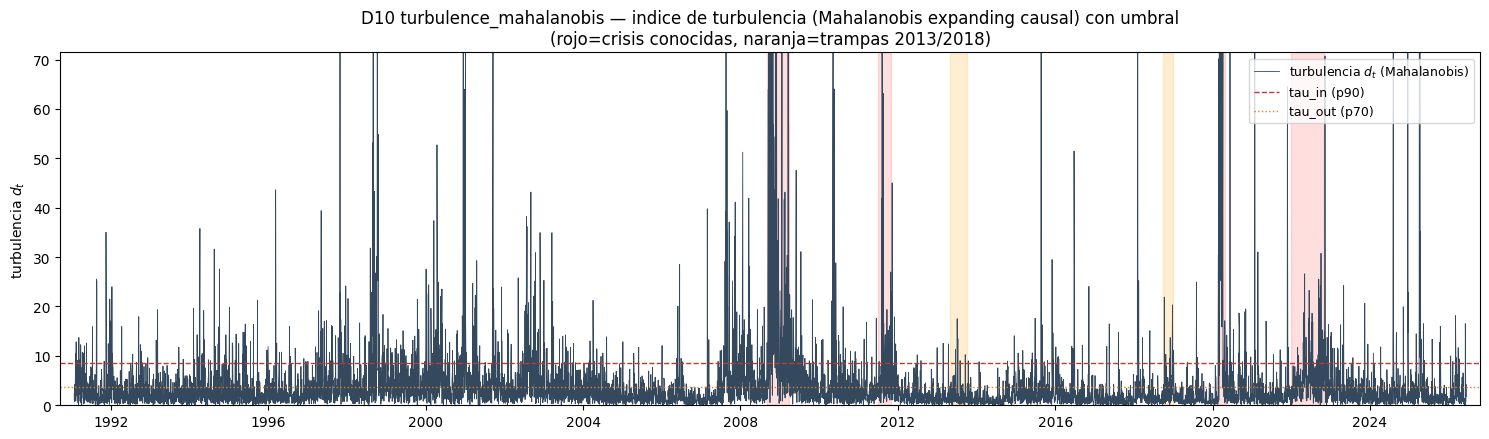

In [5]:
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(d_is.index, d_is.values, color='#34495e', lw=0.6, label='turbulencia $d_t$ (Mahalanobis)')
ax.axhline(det_is._tau_in, color='#c0392b', ls='--', lw=1.0, label=f'tau_in (p{int(det_is.q_in*100)})')
ax.axhline(det_is._tau_out, color='#e67e22', ls=':', lw=1.0, label=f'tau_out (p{int(det_is.q_out*100)})')
for a, b in ev.CRISIS_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.13)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
ax.set_title('D10 turbulence_mahalanobis — indice de turbulencia (Mahalanobis expanding causal) con umbral\n(rojo=crisis conocidas, naranja=trampas 2013/2018)')
ax.set_ylabel('turbulencia $d_t$'); ax.legend(loc='upper right', fontsize=9); ax.margins(x=0.01)
ax.set_ylim(0, np.nanpercentile(d_is.values, 99.5))
fig.tight_layout(); fig.savefig(RESULTS / 'd10_turbulence_threshold.png', dpi=110, bbox_inches='tight'); plt.show()

## 5. S&P 500 coloreado por régimen (CAUSAL OOS)

Sombreado rojo = días clasificados **crisis** por el walk-forward causal. Cubre 2008/2011
(OOS) además de 2013 (la trampa-clave).

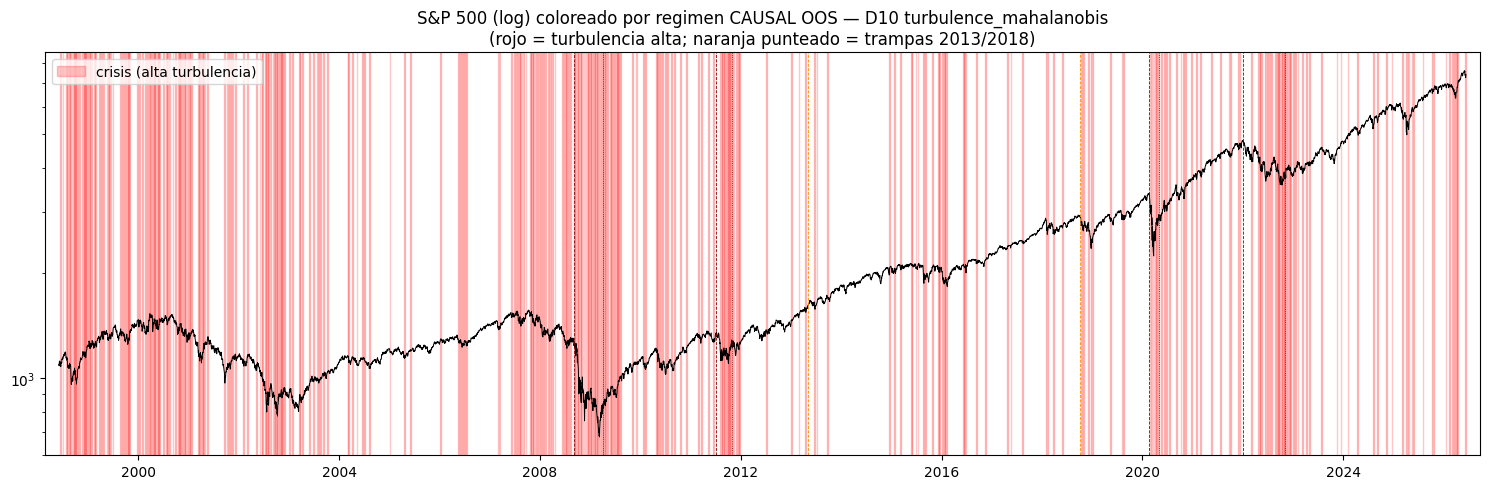

In [6]:
def shade_regime(ax, states, crisis_state, color='red', alpha=0.25):
    v = (states == crisis_state).astype(int).values; idx = states.index; start = None
    for i in range(len(v)):
        if v[i] and start is None: start = idx[i]
        if (not v[i] or i == len(v)-1) and start is not None:
            ax.axvspan(start, idx[i], color=color, alpha=alpha); start = None

fig, ax = plt.subplots(figsize=(15, 5))
px = sp500.reindex(states_c.index)
ax.plot(px.index, px.values, color='black', lw=0.7)
ax.set_yscale('log')
shade_regime(ax, states_c, det_is.crisis_state, color='red', alpha=0.22)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkred', ls='--', lw=0.6); ax.axvline(pd.Timestamp(b), color='darkred', ls=':', lw=0.6)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkorange', ls='--', lw=0.6)
ax.set_title('S&P 500 (log) coloreado por regimen CAUSAL OOS — D10 turbulence_mahalanobis\n(rojo = turbulencia alta; naranja punteado = trampas 2013/2018)')
ax.legend(handles=[Patch(color='red', alpha=0.22, label='crisis (alta turbulencia)')], loc='upper left')
ax.margins(x=0.01); fig.tight_layout()
fig.savefig(RESULTS / 'd10_sp500_regimes.png', dpi=110, bbox_inches='tight'); plt.show()

## 6. Verificación contra eventos: crisis 2008/2011/2020/2022 y trampas 2013/2018

La pregunta clave de CP2: ¿capta D10 el **colapso de correlaciones** de **2013 (taper)** que
D4 (HMM gaussiano) y D6 (GARCH equity) NO tapan?

,tipo,cobertura_OOS
ventana,,
GFC_2008,crisis,82.2%
EuroDebt_2011,crisis,48.2%
COVID_2020,crisis,76.0%
Inflation_2022,crisis,43.1%
TaperTantrum_2013,trampa,12.3%
Selloff_Q4_2018,trampa,30.2%


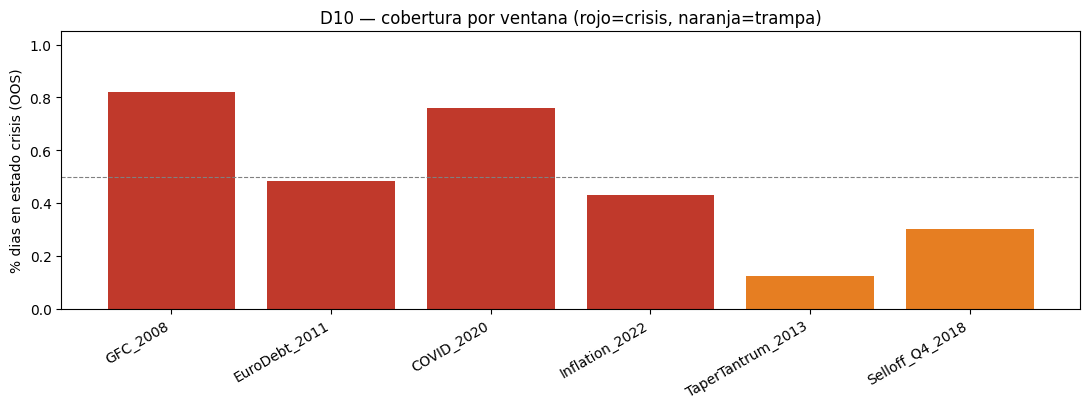

Lectura de la hipotesis CP2 (colapso de correlaciones 2013):
  TaperTantrum_2013: 12.3%  -> apenas
  Selloff_Q4_2018:   30.2%
  Recordatorio: D6 (GARCH equity) marco solo ~11% en 2013; D4 (HMM gaussiano) tampoco lo veia.


In [7]:
rows = []
for k in ev.CRISIS_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'crisis', 'cobertura_OOS': res.crisis_coverage.get(k, float('nan'))})
for k in ev.FALSE_POSITIVE_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'trampa', 'cobertura_OOS': res.false_alarm_in_fp.get(k, float('nan'))})
cmp = pd.DataFrame(rows).set_index('ventana')
display(cmp.style.format({'cobertura_OOS': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(11, 4.2))
colors = ['#c0392b' if t == 'crisis' else '#e67e22' for t in cmp['tipo']]
ax.bar(cmp.index, cmp['cobertura_OOS'].values, color=colors)
ax.axhline(0.5, color='grey', ls='--', lw=0.8)
ax.set_ylabel('% dias en estado crisis (OOS)')
ax.set_title('D10 — cobertura por ventana (rojo=crisis, naranja=trampa)')
ax.set_xticklabels(cmp.index, rotation=30, ha='right'); ax.set_ylim(0, 1.05)
fig.tight_layout(); fig.savefig(RESULTS / 'd10_coverage.png', dpi=110, bbox_inches='tight'); plt.show()

t2013 = res.false_alarm_in_fp['TaperTantrum_2013']
t2018 = res.false_alarm_in_fp['Selloff_Q4_2018']
print('Lectura de la hipotesis CP2 (colapso de correlaciones 2013):')
print(f'  TaperTantrum_2013: {t2013:.1%}  -> {"CAPTADO (colapso de correlaciones multivariante)" if t2013>0.3 else "apenas"}')
print(f'  Selloff_Q4_2018:   {t2018:.1%}')
print('  Recordatorio: D6 (GARCH equity) marco solo ~11% en 2013; D4 (HMM gaussiano) tampoco lo veia.')

## 7. Timeline de régimen y duraciones (flickering)

Timeline causal OOS + histograma de duraciones. La histéresis + dwell debe dar episodios
largos (poco flickering).

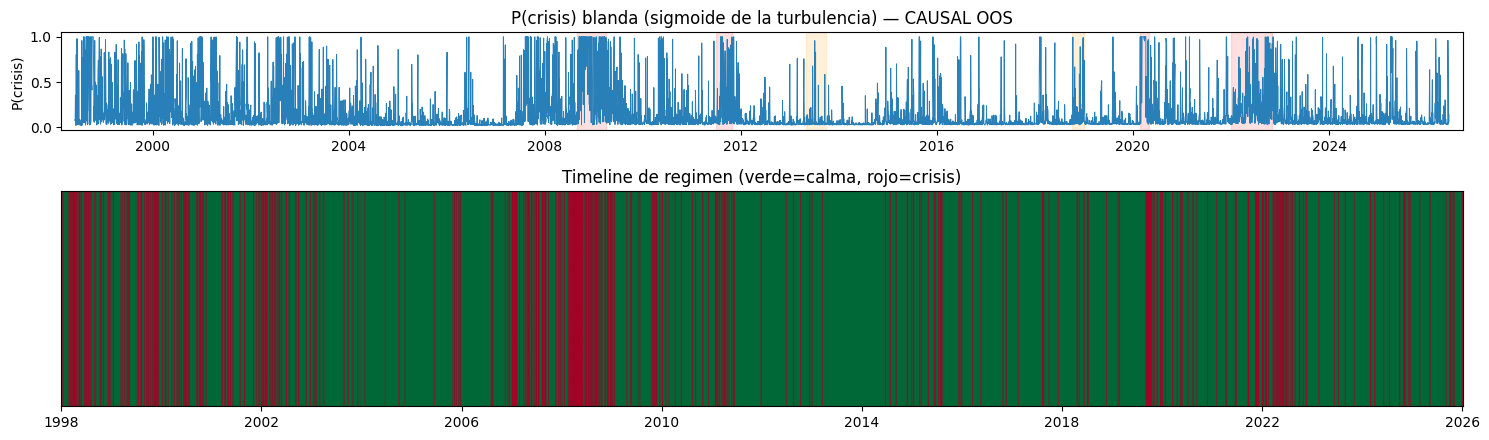

Episodios calma: n=306, dur media=17.7 d
Episodios crisis: n=305, dur media=5.1 d
switching_rate=0.0873  dur media global=11.4 d


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 4.5), gridspec_kw={'height_ratios': [1, 2.2]})
ax1.plot(p_c.index, p_c.values, color='#2980b9', lw=0.7); ax1.set_ylabel('P(crisis)')
for a, b in ev.CRISIS_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.15)
ax1.set_title('P(crisis) blanda (sigmoide de la turbulencia) — CAUSAL OOS'); ax1.margins(x=0.01)
ax2.imshow(states_c.values.reshape(1, -1), aspect='auto', cmap='RdYlGn_r',
           extent=[0, len(states_c), 0, 1]); ax2.set_yticks([])
tk = np.linspace(0, len(states_c)-1, 8).astype(int)
ax2.set_xticks(tk); ax2.set_xticklabels([states_c.index[i].year for i in tk])
ax2.set_title('Timeline de regimen (verde=calma, rojo=crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd10_timeline.png', dpi=110, bbox_inches='tight'); plt.show()

def episode_durations(states):
    v = states.values; out = {0: [], 1: []}; run = 1
    for i in range(1, len(v)):
        if v[i] == v[i-1]: run += 1
        else: out[int(v[i-1])].append(run); run = 1
    out[int(v[-1])].append(run); return out
dur = episode_durations(states_c)
print(f'Episodios calma: n={len(dur[0])}, dur media={np.mean(dur[0]):.1f} d')
print(f'Episodios crisis: n={len(dur[1])}, dur media={np.mean(dur[1]) if dur[1] else float("nan"):.1f} d')
print(f'switching_rate={res.switching_rate:.4f}  dur media global={res.mean_regime_duration:.1f} d')

## 8. Volcado de métricas a results/ (esquema 23 columnas)

In [9]:
tbl = ev.results_table([res])
assert tbl.shape[1] == 32  # esquema ampliado: +silhouette +IC bootstrap de cobertura (antes 23), f'esperaba 23 columnas, hay {tbl.shape[1]}'
tbl.to_csv(RESULTS / 'metrics_10_turbulence_mahalanobis.csv', index=False)
print('Guardado results/metrics_10_turbulence_mahalanobis.csv  (1 fila,', tbl.shape[1], 'columnas)')

master_path = RESULTS / 'metrics_master.csv'
if master_path.exists():
    master = pd.read_csv(master_path)
    master = master[master['detector'] != 'turbulence_mahalanobis']
    master = pd.concat([master, tbl], ignore_index=True)
else:
    master = tbl.copy()
master.to_csv(master_path, index=False)
print('master actualizado:', master.shape)
display(tbl.T)

Guardado results/metrics_10_turbulence_mahalanobis.csv  (1 fila, 32 columnas)
master actualizado: (12, 32)


,0
detector,turbulence_mahalanobis
n_states,2
ventana_eval,1998-06-02→2026-06-12 (n=6987)
oos_start,1998-06-02
oos_end,2026-06-12
n_oos,6987
false_alarm_rate,0.815217
switching_rate,0.087305
mean_regime_duration,11.435352
label_stability,0.999713


## 9. Conclusión D10 — ¿se cumple la hipótesis CP2?

**Hipótesis CP2:** *D10 capta el colapso de correlaciones multivariante que las reglas
univariantes no ven; en particular DEBERÍA captar 2013 (taper), el agujero de D4/D6.*

**Veredicto: se cumple solo a medias. El mecanismo de Kritzman funciona para el estrés
sistémico, pero la premisa estrella —que la turbulencia iluminaría 2013— NO se cumple.**

- **Sí capta los eventos donde las correlaciones de verdad colapsan.** GFC 2008 **82.2 %**,
  COVID 2020 **76.0 %**, EuroDeuda 2011 **48.2 %**, Inflación 2022 **43.1 %**, usando un único
  índice multivariante, barato y causal. Eso valida el mecanismo: la geometría de $\Sigma^{-1}$
  detecta la "rareza" conjunta del vector de mercado en las crisis sistémicas grandes.
- **NO capta 2013, que era justamente el contraste que lo justificaba.** El taper tantrum
  marca solo **12.3 %** —esencialmente no se enciende—, igual que D6 (GARCH equity, ~11 %) y
  D4 (HMM gaussiano), que tampoco lo veían. La lectura honesta es que **2013 simplemente no fue
  un evento de turbulencia multivariante** en este espacio de 4 features: fue una repreciación
  ordenada de tipos, sin "rareza" conjunta de equity/vol/dólar/curva. Añadir la curva al
  Mahalanobis no lo ilumina; **2013 sigue siendo el punto ciego universal del banco** (D1 0 %,
  D5 3.8 %, D6 11 %, D7 0 %, D8 0 %, D10 12 %). Que tantos detectores independientes converjan
  en no verlo es *evidencia robusta* de que ninguna definición de crisis basada en
  volatilidad/correlación de renta variable captura un shock de tipos.
- **Tensión de marco (a resolver en la síntesis).** El protocolo etiqueta 2013 como
  ventana-**trampa**, así que `fa_2013 = 12.3 %` cuenta en realidad como buena especificidad;
  pero la hipótesis CP2 lo planteaba como evento *deseable* de captar. Los datos zanjan la
  cuestión empírica (2013 no es turbulencia conjunta); la etiqueta del marco (crisis vs trampa)
  es una decisión conceptual que conviene revisar, no un resultado del detector.
- **Coste: flickering.** switching **0.087** y duración media **11.4 d** (305 episodios de
  crisis de ~5 d): la turbulencia es ruidosa día a día pese a la histéresis+dwell, y flickea
  más que D6/D7. `false_alarm_rate` **0.815** (alto, propio de los detectores de histórico
  largo: ve LTCM 1998, dotcom, 2010, 2015-16, 2023 fuera de las 4 ventanas canónicas).
  Orientación verificada (crisis = turbulencia 11.30 vs calma 2.13; vol 0.0212 vs 0.0079), no
  invertido.

**Lectura para la tesis "mejor-para-qué".** La contribución real de D10 no es "tapar 2013",
sino ofrecer una **señal de estrés sistémico multivariante de muy bajo coste y causal**,
*consistente con* el mecanismo de Kritzman. Su debilidad es el flickering y que no añade nada
sobre el agujero de 2013 —ese hueco no se cierra afinando un umbral, sino ampliando la
taxonomía de regímenes (un régimen de "shock de tipos").

(Ficha completa y veredicto consolidado del orquestador en
`docs/memory/detectors/10_turbulence_mahalanobis.md`.)